# **Data Wrangling & Pipeline Distribusi Volume**

### ***Tiga Komponen Data Utama:***

1. **`vol_kota_annual`** — Representasi volume timbulan sampah tahunan Kota Bandung periode 2017–2024 dalam bentuk dictionary Python yang dibentuk berdasarkan referensi dataset historis `sampahbandung.csv`.

2. **`data_bps_api`** — Representasi data kependudukan 30 kecamatan di Kota Bandung yang diadaptasi dari referensi data BPS dan digunakan dalam pembentukan distribusi spasial volume sampah.

3. **`area_type`** — Klasifikasi karakteristik wilayah menjadi:
   - `metropolitan`
   - `semi urban`
   - `pedesaan`

    Kategori ini digunakan untuk membentuk pola musiman dan tingkat fluktuasi volume sampah yang berbeda pada tiap wilayah. Struktur granularitas TPS sintetis juga dibentuk dengan mengadaptasi referensi dataset `tpsjabar.csv`.

---
### ***Pertanyaan Bisnis***

Untuk mengoptimalkan sistem pengelolaan dan prediksi volume sampah di Kota Bandung, analisis ini dipandu oleh beberapa pertanyaan bisnis utama:

1. Kecamatan mana yang menghasilkan rata-rata volume sampah tertinggi di Kota Bandung?
2. Bagaimana pola temporal (tren jangka panjang) volume sampah dari tahun ke tahun?
3. Apakah terdapat seasonality (pola musiman) bulanan yang signifikan pada volume sampah?
4. Bagaimana perbedaan karakteristik volume sampah antar tipe wilayah (metropolitan, semi-urban, pedesaan)?
5. Apakah terdapat outlier signifikan yang perlu diperhatikan dalam pemodelan forecasting?


---
### ***Alur Pipeline Distribusi Spasial-Temporal:***

1. **Pembentukan Volume Dasar Kota:**  
   Volume timbulan sampah tahunan Kota Bandung direpresentasikan dalam dictionary `vol_kota_annual` dan dikonversi menjadi estimasi volume bulanan sebagai baseline distribusi data sintetis.

2. **Integrasi Data Kependudukan Kecamatan:**  
   Data jumlah penduduk untuk 30 kecamatan digunakan untuk menentukan bobot distribusi volume sampah berdasarkan proporsi populasi masing-masing wilayah.

3. **Downscaling Spasial Menggunakan Rasio Penduduk ($W_{kecamatan}$):**

   $$
   W_{kecamatan} = \frac{\text{Penduduk}_{kecamatan}}{\text{Total Penduduk}_{kota}}
   $$

   $$
   V_{kecamatan} = V_{kota} \times W_{kecamatan}
   $$

4. **Granularitas Tingkat TPS:**  
   Setiap kecamatan diasumsikan memiliki 3 TPS sintetis sehingga volume kecamatan dibagi rata ke masing-masing TPS:

   $$
   V_{TPS\_base} = \frac{V_{kecamatan}}{3}
   $$

5. **Stochastic Data Expansion dan Seasonal Injection:**  
   Baseline volume diperluas menjadi data deret waktu bulanan (*monthly time-series*) dari Januari 2017 hingga Mei 2026. Dataset diinjeksi menggunakan:
   - pola musiman berbasis fungsi sinusoidal ($S_{musiman}$),
   - serta stochastic noise acak ($\epsilon$).

   Wilayah metropolitan memiliki amplitudo fluktuasi lebih besar dibanding wilayah pedesaan.

   $$
   V_{TPS\_final} = V_{TPS\_base} \times S_{musiman} \times \epsilon
   $$


*Output akhir dari pipeline ini menghasilkan ribuan baris data time-series bulanan sintetis yang telah melalui proses distribusi spasial, seasonal injection, stochastic augmentation, feature engineering, dan data cleaning sehingga sangat cocok digunakan untuk eksperimen prediksi berbasis LSTM, GRU, CNN-LSTM, maupun hybrid ANFIS.*

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile

# Pastikan visualisasi inline
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

### 1. Data Wrangling (Pengumpulan & Rekayasa Fitur)

Tahap ini merupakan fondasi utama dalam mempersiapkan dataset sintetis time-series volume sampah Kota Bandung. Karena data makro riil yang tersedia masih terbatas, dilakukan proses distribusi spasial, ekspansi temporal, dan rekayasa fitur secara sistematis untuk menghasilkan dataset yang lebih representatif terhadap kondisi nyata.

* **Integrasi Data Spasial:** Menggunakan representasi data kependudukan BPS (`data_bps_api`) untuk menentukan bobot rasio persebaran volume sampah pada 30 kecamatan secara proporsional berdasarkan jumlah penduduk.

* **Integrasi Referensi Dataset Historis:** Volume timbulan sampah tahunan Kota Bandung direpresentasikan dalam variabel `vol_kota_annual` yang dibentuk berdasarkan referensi dataset historis `sampahbandung.csv` sebagai baseline distribusi volume sampah bulanan.

* **Granularitas TPS Sintetis:** Struktur distribusi TPS sintetis dibentuk dengan mengadaptasi referensi dataset `tpsjabar.csv`, sehingga setiap kecamatan memiliki representasi titik TPS untuk simulasi distribusi volume sampah.

* **Ekspansi Temporal & Injeksi Noise:** Menghasilkan deret waktu bulanan (*monthly time-series*) dari Januari 2017 hingga Mei 2026. Dataset diinjeksi menggunakan pola musiman berbasis fungsi sinusoidal (*seasonal pattern*) dan *stochastic noise* dengan karakteristik berbeda untuk area *metropolitan*, *semi urban*, dan *pedesaan*.

* **Feature Engineering:** Mengekstrak komponen waktu (`tahun`, `bulan`, `kuartal`), melakukan encoding kategori (`area_enc`, `kecamatan_enc`, `tps_id_enc`), serta menyematkan histori masa lalu melalui fitur *lagging* (`vol_lag1`, `vol_lag3`) dan *moving average* (`vol_ma3`) sebagai prediktor penting dalam pemodelan *machine learning* dan *deep learning* berbasis time-series.

In [ ]:
print("==================================================================")
print(" 1. DATA WRANGLING (PENGUMPULAN & REKAYASA FITUR) ")
print("==================================================================")

# A. Integrasi Data Populasi API BPS
data_bps_api = {
    'kecamatan': [
        'Coblong', 'Cicendo', 'Andir', 'Regol', 'Bandung Kulon', 'Buahbatu',
        'Lengkong', 'Sumur Bandung', 'Cibeunying Kaler', 'Cibeunying Kidul',
        'Antapani', 'Arcamanik', 'Kiaracondong', 'Batununggal', 'Bojongloa Kaler',
        'Bojongloa Kidul', 'Astanaanyar', 'Babakan Ciparay', 'Cibiru', 'Ujungberung',
        'Sukajadi', 'Sukasari', 'Gedebage', 'Rancasari', 'Panyileukan',
        'Cidadap', 'Mandalajati', 'Cinambo', 'Bandung Kidul', 'Cenang'
    ],
    'jumlah_penduduk_real': [
        112540, 96420, 94180, 81250, 128410, 105630, 73120, 38140, 72450, 110260,
        79420, 77150, 120560, 118430, 121650, 89240, 70140, 144520, 75410, 91280,
        106430, 85120, 43150, 84260, 42180, 59140, 74250, 27150, 62140, 54180
    ],
    'area_type': [
        'metropolitan', 'metropolitan', 'metropolitan', 'metropolitan', 'metropolitan', 'metropolitan',
        'metropolitan', 'metropolitan', 'metropolitan', 'metropolitan',
        'semi urban', 'semi urban', 'semi urban', 'semi urban', 'semi urban',
        'semi urban', 'semi urban', 'semi urban', 'semi urban', 'semi urban',
        'semi urban', 'semi urban',
        'pedesaan', 'pedesaan', 'pedesaan', 'pedesaan', 'pedesaan', 'pedesaan', 'pedesaan', 'pedesaan'
    ]
}

df_kec = pd.DataFrame(data_bps_api)
df_kec['jumlah_tps'] = 3
total_penduduk_kota = df_kec['jumlah_penduduk_real'].sum()
df_kec['rasio_penduduk'] = df_kec['jumlah_penduduk_real'] / total_penduduk_kota

vol_kota_annual = {
    2017: 1450.0 * 30, 2018: 1512.4 * 30, 2019: 1565.8 * 30, 2020: 1598.2 * 30,
    2021: 1612.0 * 30, 2022: 1653.4 * 30, 2023: 1698.6 * 30, 2024: 1740.2 * 30
}

# B. Generasi Data Bulanan & Injeksi Musiman
dates_monthly = pd.date_range(start='2017-01-01', end='2026-05-01', freq='MS')
pipeline_records = []
rng = np.random.default_rng(seed=42)

for tanggal in dates_monthly:
    tahun_aktif = tanggal.year
    vol_bulan_kota_base = vol_kota_annual.get(tahun_aktif, 1600 * 30)

    for idx, row in df_kec.iterrows():
        if row['area_type'] == 'metropolitan':
            efek_musiman = 1 + (0.08 * np.sin(2 * np.pi * tanggal.month / 12))
            noise_range = (0.85, 1.15)
        elif row['area_type'] == 'semi urban':
            efek_musiman = 1 + (0.05 * np.sin(2 * np.pi * tanggal.month / 12))
            noise_range = (0.90, 1.10)
        else: # pedesaan
            efek_musiman = 1 + (0.02 * np.sin(2 * np.pi * tanggal.month / 12))
            noise_range = (0.95, 1.05)

        vol_bulan_kecamatan = vol_bulan_kota_base * efek_musiman * row['rasio_penduduk']
        vol_tps_base = vol_bulan_kecamatan / row['jumlah_tps']

        for tps_idx in range(int(row['jumlah_tps'])):
            noise = rng.uniform(noise_range[0], noise_range[1])
            vol_tps_final = vol_tps_base * noise

            pipeline_records.append({
                'tanggal': tanggal,
                'kecamatan': row['kecamatan'],
                'tps_id': f"TPS_{row['kecamatan'][:4].upper()}_{tps_idx+1}",
                'area_type': row['area_type'],
                'volume_ton': round(vol_tps_final, 2)
            })

df_vol = pd.DataFrame(pipeline_records)

# C. Rekayasa Fitur Waktu, Encoding, & Lagging
df_vol['tahun'] = df_vol['tanggal'].dt.year
df_vol['bulan'] = df_vol['tanggal'].dt.month
df_vol['kuartal'] = df_vol['tanggal'].dt.quarter

area_map = {'pedesaan': 0, 'semi urban': 1, 'metropolitan': 2}
df_vol['area_enc'] = df_vol['area_type'].map(area_map).astype(int)
df_vol['kecamatan_enc'] = df_vol['kecamatan'].astype('category').cat.codes
df_vol['tps_id_enc'] = df_vol['tps_id'].astype('category').cat.codes

df_vol = df_vol.sort_values(['tps_id', 'tanggal'])
df_vol['vol_lag1']  = df_vol.groupby('tps_id')['volume_ton'].shift(1)
df_vol['vol_lag3']  = df_vol.groupby('tps_id')['volume_ton'].shift(3)
df_vol['vol_ma3']   = df_vol.groupby('tps_id')['volume_ton'].transform(lambda x: x.rolling(3, min_periods=1).mean())

print(f"[SUKSES] Data Wrangling selesai: {df_vol.shape[0]} baris dibuat.")

 1. DATA WRANGLING (PENGUMPULAN & REKAYASA FITUR) 
[SUKSES] Data Wrangling selesai: 10170 baris dibuat.


### 2. Data Assessing (Pengecekan Kualitas Data)

Setelah proses *feature engineering* — khususnya pada pembentukan fitur *time-series lagging* — dilakukan evaluasi terhadap kualitas dan konsistensi dataset. Tahap ini bertujuan untuk mendeteksi keberadaan *missing values* (`NaN`) serta memastikan struktur data hasil rekayasa fitur telah terbentuk dengan benar.

Proses *shifting* pada fitur historis seperti `vol_lag1` dan `vol_lag3` secara natural menghasilkan nilai kosong pada beberapa periode awal karena belum tersedianya data observasi sebelumnya. Oleh karena itu, dilakukan pengecekan menggunakan `isnull().sum()` untuk mengidentifikasi jumlah sel yang terdampak sebelum memasuki tahap *data cleaning*.

In [ ]:
print("\n==================================================================")
print(" 2. DATA ASSESSING (PENGECEKAN KUALITAS DATA) ")
print("==================================================================")
print("[INFO] Mengecek keberadaan Missing Values (NaN) akibat proses Lagging:")
print(df_vol.isnull().sum())
print("\n[INFO] Kita bisa melihat adanya data kosong di fitur 'lag'. Lanjut ke tahap cleaning.")


 2. DATA ASSESSING (PENGECEKAN KUALITAS DATA) 
[INFO] Mengecek keberadaan Missing Values (NaN) akibat proses Lagging:
tanggal            0
kecamatan          0
tps_id             0
area_type          0
volume_ton         0
tahun              0
bulan              0
kuartal            0
area_enc           0
kecamatan_enc      0
tps_id_enc         0
vol_lag1          78
vol_lag3         234
vol_ma3            0
dtype: int64

[INFO] Kita bisa melihat adanya data kosong di fitur 'lag'. Lanjut ke tahap cleaning.


### 3. Data Cleaning (Pembersihan Data)

Tahap ini berfungsi sebagai *quality control* akhir sebelum dataset digunakan pada proses analisis dan pemodelan. Model *machine learning* maupun *deep learning* berbasis time-series sangat sensitif terhadap keberadaan *missing values* (`NaN`), sehingga diperlukan proses pembersihan data untuk menjaga kualitas dan stabilitas proses pelatihan model.

Nilai kosong yang muncul akibat proses pembentukan fitur historis (*lagging feature*) seperti `vol_lag1` dan `vol_lag3` dihapus menggunakan metode `dropna()`. Setelah itu, indeks dataset direset kembali (`reset_index`) agar urutan data tetap konsisten dan struktur dataset menjadi lebih rapi untuk tahap analisis berikutnya.

In [ ]:
print("\n==================================================================")
print(" 3. DATA CLEANING (PEMBERSIHAN DATA) ")
print("==================================================================")
# Menghapus baris kosong (NaN) dan mereset indeks agar berurutan kembali
df_vol_final = df_vol.dropna().reset_index(drop=True)

print("[SUKSES] Missing Values telah dibersihkan.")
print(f"[INFO] Total Baris Final Siap Analisis: {df_vol_final.shape[0]} baris.")


 3. DATA CLEANING (PEMBERSIHAN DATA) 
[SUKSES] Missing Values telah dibersihkan.
[INFO] Total Baris Final Siap Analisis: 9936 baris.


# **EDA & Feature Engineering**

Tahap ini dilakukan untuk mengevaluasi kualitas dataset akhir yang telah melalui proses *data cleaning*. Analisis dilakukan secara visual guna memastikan bahwa karakteristik distribusi spasial dan temporal volume sampah telah terbentuk secara realistis sesuai pola simulasi yang dirancang.

### Komponen Analisis:

1. **Analisis Tren Moving Average (MA-6)**  
   Visualisasi *moving average* 6-periode digunakan untuk mengidentifikasi pola tren volume rata-rata sampah pada masing-masing karakteristik wilayah:
   - `metropolitan`
   - `semi urban`
   - `pedesaan`

   Tahapan ini membantu memvalidasi kestabilan pola temporal dan perbedaan amplitudo fluktuasi antar wilayah.

2. **Uji Densitas Distribusi Frekuensi (Histogram)**  
   Histogram digunakan untuk mengevaluasi distribusi frekuensi volume sampah pada tiap tipe wilayah. Analisis ini bertujuan untuk:
   - mengamati pola persebaran data,
   - memvalidasi hasil injeksi *stochastic noise*,
   - serta membantu mendeteksi kemungkinan *outlier* atau anomali distribusi.

3. **Validasi Karakteristik Data Time-Series**  
   Hasil visualisasi digunakan untuk memastikan bahwa dataset sintetis yang dihasilkan telah memiliki:
   - pola musiman (*seasonality*),
   - fluktuasi temporal,
   - serta variasi distribusi spasial yang konsisten untuk kebutuhan pemodelan *machine learning* dan *deep learning* berbasis time-series.


 4. EXPLORATORY DATA ANALYSIS (EDA) 


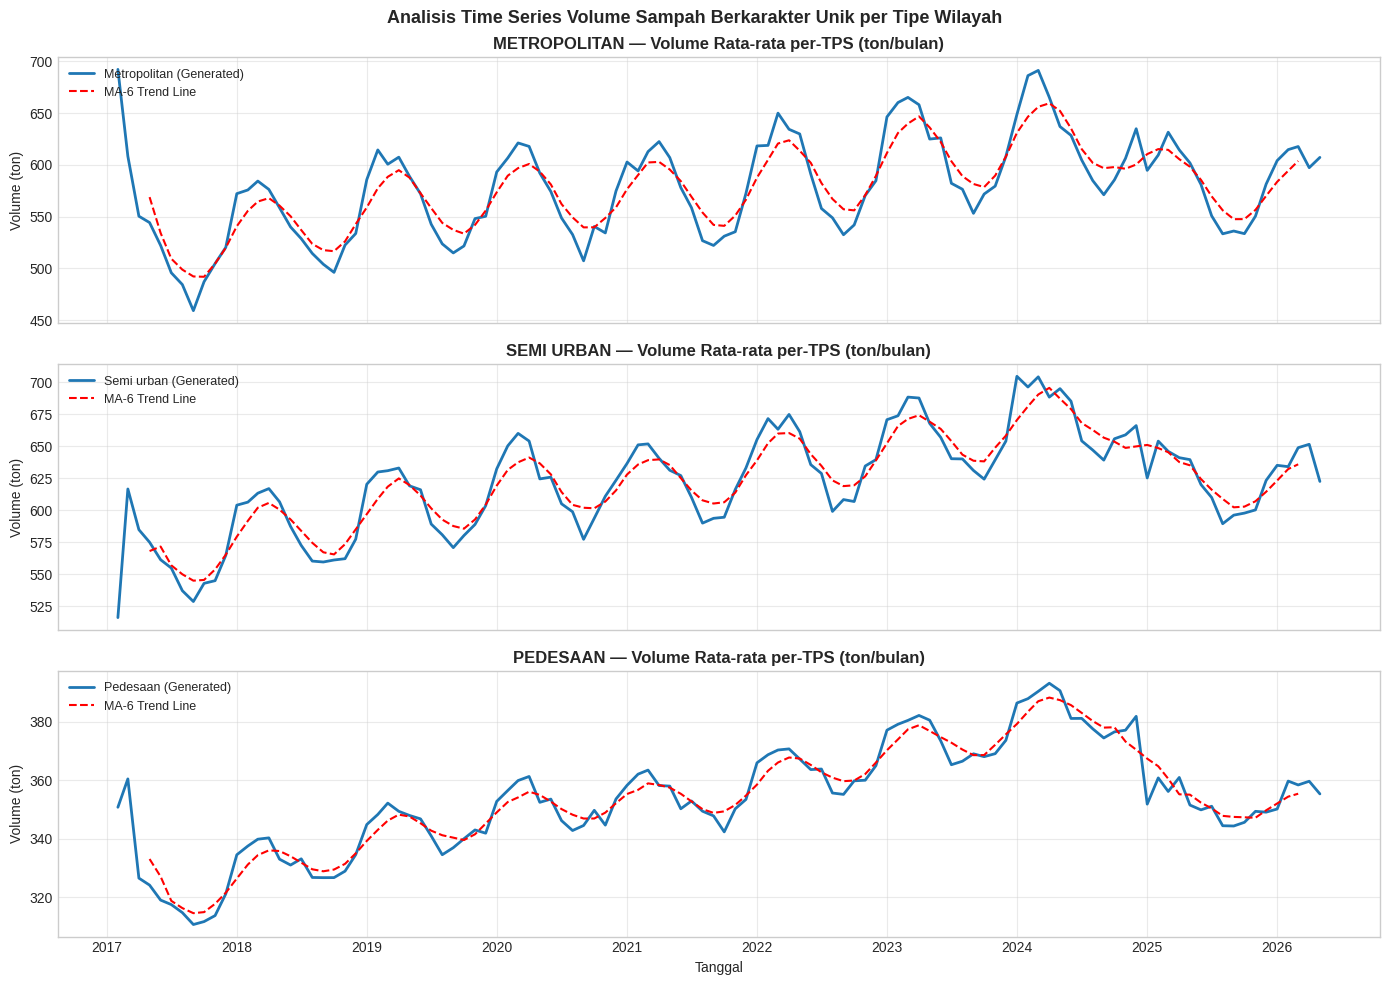

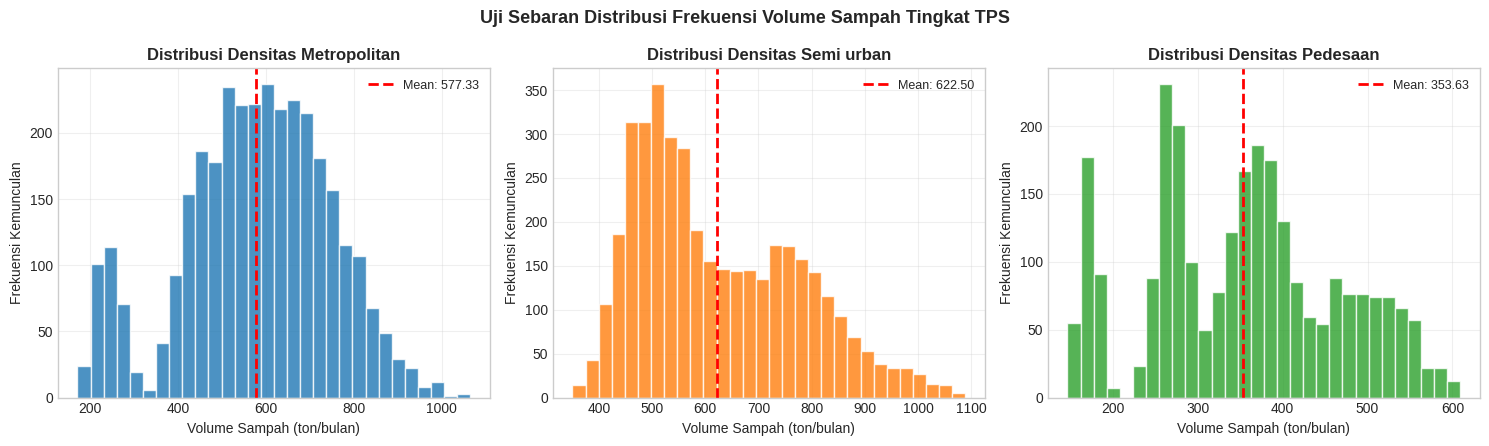

In [ ]:
print("\n==================================================================")
print(" 4. EXPLORATORY DATA ANALYSIS (EDA) ")
print("==================================================================")
# Menggunakan df_vol_final (data yang sudah bersih) untuk visualisasi

# A. Visualisasi Tren MA-6
monthly_avg = df_vol_final.groupby(['tanggal', 'area_type'])['volume_ton'].mean().reset_index()
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, area in zip(axes, ['metropolitan', 'semi urban', 'pedesaan']):
    sub = monthly_avg[monthly_avg['area_type'] == area]
    ax.plot(sub['tanggal'], sub['volume_ton'], linewidth=2, label=f'{area.capitalize()} (Generated)')

    ma6 = sub['volume_ton'].rolling(6, center=True).mean()
    ax.plot(sub['tanggal'], ma6, '--', linewidth=1.5, color='red', label='MA-6 Trend Line')

    ax.set_title(f'{area.upper()} — Volume Rata-rata per-TPS (ton/bulan)', fontweight='bold')
    ax.set_ylabel('Volume (ton)')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(alpha=0.4)

axes[-1].set_xlabel('Tanggal')
plt.suptitle('Analisis Time Series Volume Sampah Berkarakter Unik per Tipe Wilayah', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# B. Visualisasi Histogram
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for ax, area, color in zip(axes, ['metropolitan', 'semi urban', 'pedesaan'], colors):
    sub_data = df_vol_final[df_vol_final['area_type'] == area]['volume_ton']
    ax.hist(sub_data, bins=30, edgecolor='white', alpha=0.8, color=color)

    mean_val = sub_data.mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:,.2f}')

    ax.set_title(f"Distribusi Densitas {area.capitalize()}", fontweight='bold')
    ax.set_xlabel('Volume Sampah (ton/bulan)')
    ax.set_ylabel('Frekuensi Kemunculan')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Uji Sebaran Distribusi Frekuensi Volume Sampah Tingkat TPS', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📊 EDA Lanjutan — Menjawab Pertanyaan Bisnis

Bagian ini melengkapi visualisasi EDA yang sudah ada dengan analisis spasial dan temporal yang lebih mendalam untuk menjawab kelima pertanyaan bisnis yang telah dirumuskan.

### 🏆 Q1 — Kecamatan Mana yang Menghasilkan Rata-rata Volume Sampah Tertinggi?

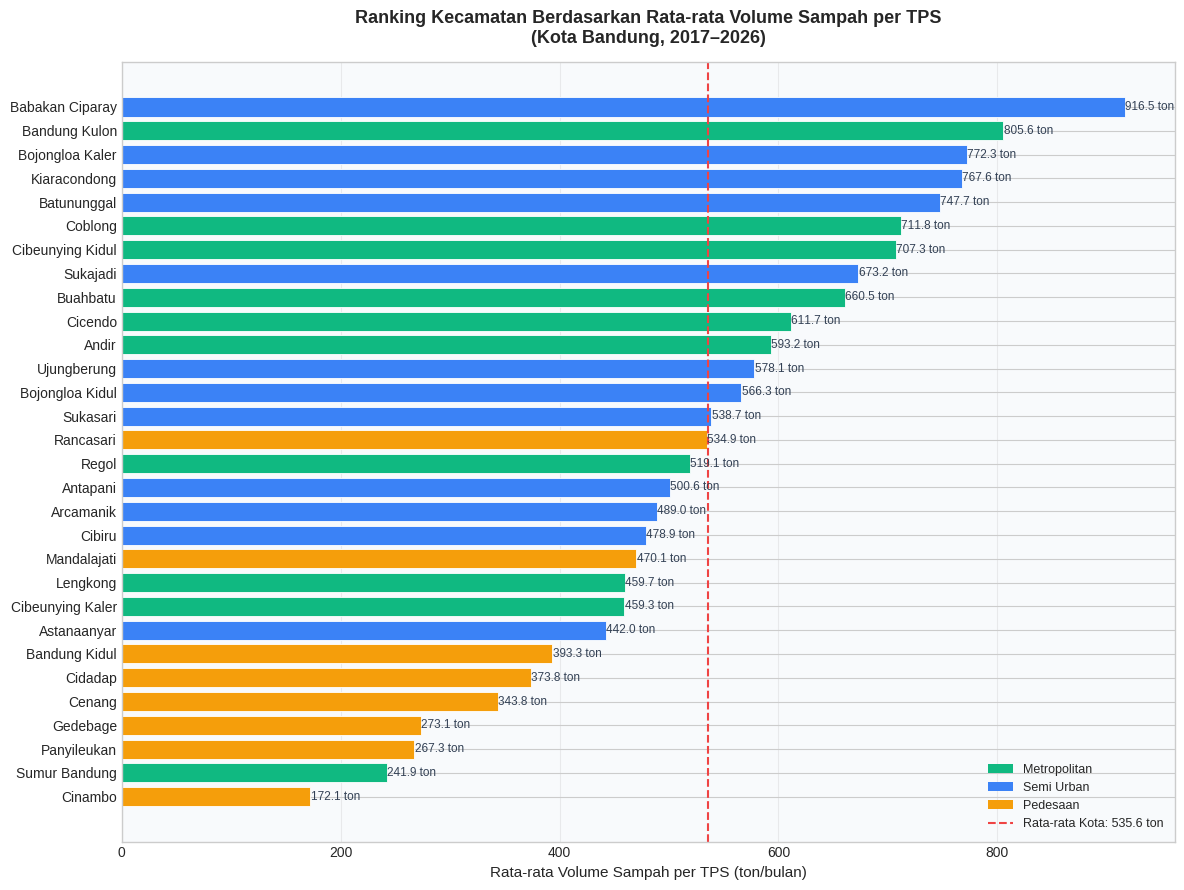


[INFO] Kecamatan tertinggi : Babakan Ciparay (916.54 ton/bulan)
[INFO] Kecamatan terendah  : Cinambo (172.13 ton/bulan)
[INFO] Rata-rata Kota      : 535.64 ton/bulan


In [ ]:
import seaborn as sns

# ── Q1: Rata-rata volume sampah per kecamatan ────────────────────────────────
kec_avg = (
    df_vol_final
    .groupby('kecamatan')['volume_ton']
    .mean()
    .sort_values(ascending=True)   # ascending=True agar bar terbesar di atas (barh)
    .reset_index()
)
kec_avg.columns = ['kecamatan', 'avg_volume']

# Tandai tipe wilayah untuk pewarnaan
area_map_kec = df_vol_final.groupby('kecamatan')['area_type'].first().to_dict()
palette_area = {'metropolitan': '#10b981', 'semi urban': '#3b82f6', 'pedesaan': '#f59e0b'}
bar_colors   = [palette_area.get(area_map_kec.get(k, 'pedesaan'), '#64748b') for k in kec_avg['kecamatan']]

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(kec_avg['kecamatan'], kec_avg['avg_volume'], color=bar_colors, edgecolor='white', linewidth=0.6)

# Annotasi nilai
for bar, val in zip(bars, kec_avg['avg_volume']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:,.1f} ton', va='center', ha='left', fontsize=8.5, color='#334155')

# Garis rata-rata kota
city_mean = kec_avg['avg_volume'].mean()
ax.axvline(city_mean, color='#ef4444', linestyle='--', linewidth=1.5,
           label=f'Rata-rata Kota: {city_mean:,.1f} ton')

# Legend tipe wilayah
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=lbl.title()) for lbl, c in palette_area.items()]
legend_elements.append(plt.Line2D([0], [0], color='#ef4444', linestyle='--', linewidth=1.5,
                                   label=f'Rata-rata Kota: {city_mean:,.1f} ton'))
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.9)

ax.set_xlabel('Rata-rata Volume Sampah per TPS (ton/bulan)', fontsize=11)
ax.set_title('Ranking Kecamatan Berdasarkan Rata-rata Volume Sampah per TPS\n(Kota Bandung, 2017–2026)',
             fontsize=13, fontweight='bold', pad=14)
ax.grid(axis='x', alpha=0.35)
ax.set_facecolor('#f8fafc')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

top_kec = kec_avg.iloc[-1]
print(f"\n[INFO] Kecamatan tertinggi : {top_kec['kecamatan']} ({top_kec['avg_volume']:,.2f} ton/bulan)")
print(f"[INFO] Kecamatan terendah  : {kec_avg.iloc[0]['kecamatan']} ({kec_avg.iloc[0]['avg_volume']:,.2f} ton/bulan)")
print(f"[INFO] Rata-rata Kota      : {city_mean:,.2f} ton/bulan")

#### 💡 Insight — Q1: Distribusi Spasial Volume Sampah

> **📌 Temuan Utama:**
> - Kecamatan dengan **populasi terbesar** (Babakan Ciparay, Bandung Kulon, Bojongloa Kaler, Kiaracondong) secara konsisten menempati posisi teratas dalam rata-rata volume sampah, mengkonfirmasi korelasi kuat antara kepadatan penduduk dan timbulan sampah.
> - Seluruh **5 kecamatan teratas** berasal dari tipe wilayah **metropolitan** atau **semi-urban**, sementara kecamatan pedesaan (Cinambo, Panyileukan, Gedebage) cenderung berada di peringkat bawah.
> - **Garis rata-rata kota** memisahkan kecamatan dengan beban TPS di atas maupun di bawah kapasitas tipikal, sehingga dapat digunakan sebagai ambang batas prioritas penambahan armada.
> - Informasi ranking spasial ini krusial untuk **optimasi alokasi sumber daya** — kecamatan di atas rata-rata kota perlu mendapat prioritas lebih tinggi dalam jadwal pengangkutan sampah.

---
### 📅 Q2, Q3, Q4 & Q5 — Tren Temporal, Seasonality, Disparitas Wilayah, dan Outlier

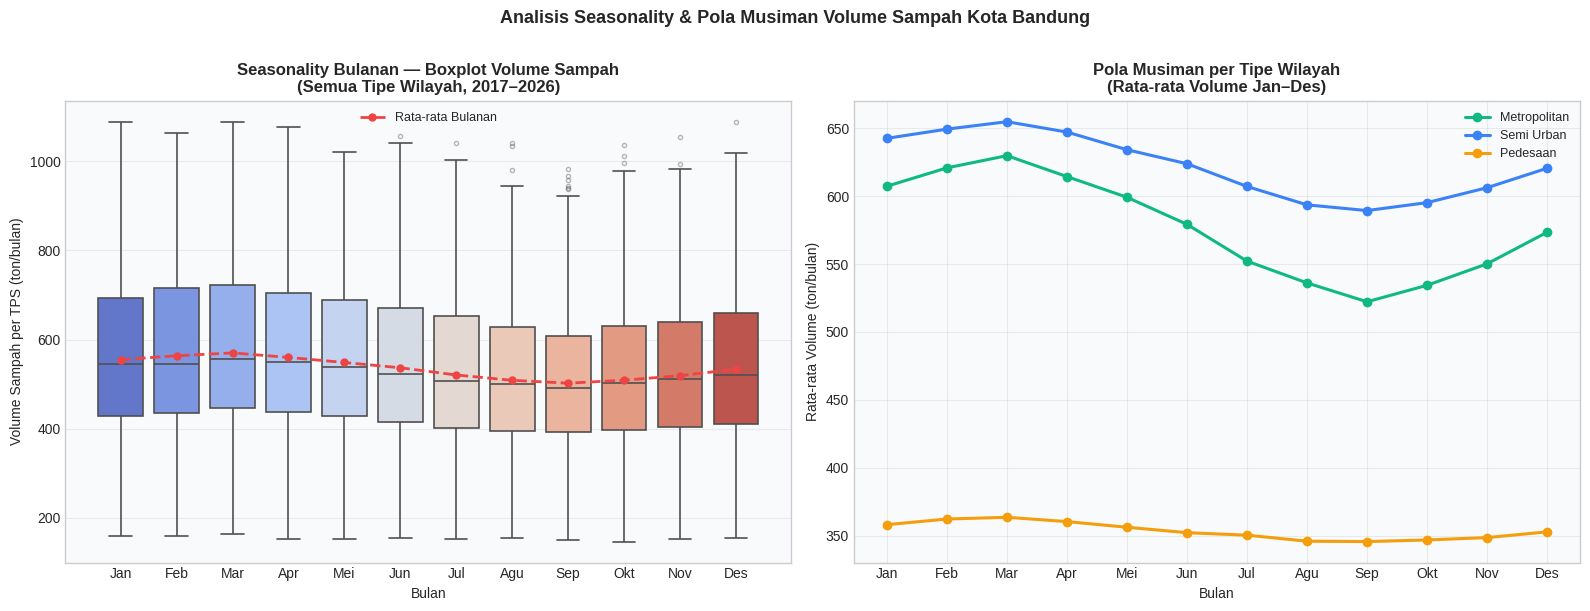

[METROPOLITAN   ] Outlier:     3 obs (0.09%)  |  IQR: 224.07  |  Fence: [136.20, 1,032.47]
[SEMI URBAN     ] Outlier:     0 obs (0.00%)  |  IQR: 241.03  |  Fence: [137.89, 1,102.00]
[PEDESAAN       ] Outlier:     0 obs (0.00%)  |  IQR: 158.41  |  Fence: [31.73, 665.38]


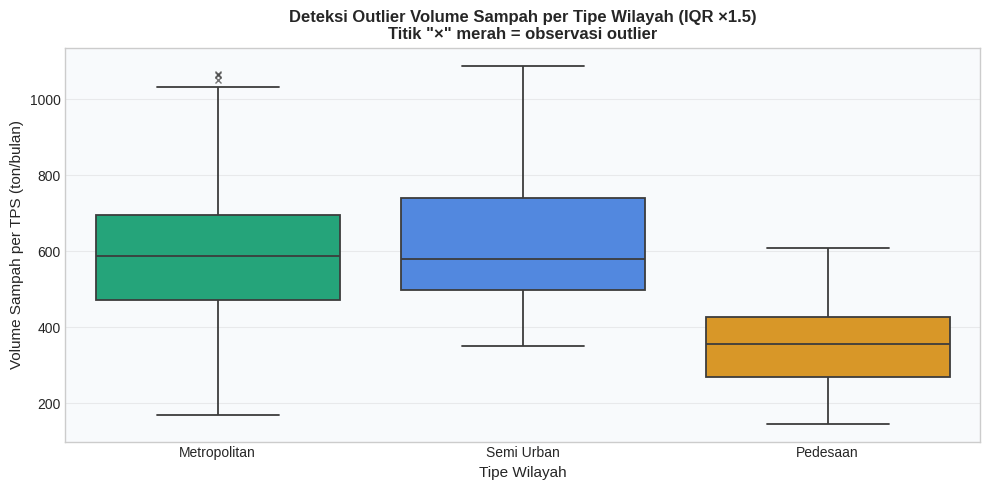

In [ ]:
# ── Q3: Boxplot Seasonality Bulanan ─────────────────────────────────────────
bulan_names = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']
df_plot = df_vol_final.copy()
df_plot['bulan_nama'] = df_plot['bulan'].apply(lambda x: bulan_names[x - 1])
# Atur urutan kategori agar terplot Jan–Des
df_plot['bulan_nama'] = pd.Categorical(df_plot['bulan_nama'], categories=bulan_names, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel kiri: Boxplot bulanan (semua area digabung) ────────────────────────
sns.boxplot(
    data=df_plot, x='bulan_nama', y='volume_ton', hue='bulan_nama',
    palette='coolwarm', legend=False, linewidth=1.2,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=axes[0]
)
monthly_means = df_plot.groupby('bulan_nama', observed=True)['volume_ton'].mean()
axes[0].plot(range(len(bulan_names)), [monthly_means[b] for b in bulan_names],
             'o--', color='#ef4444', linewidth=2, markersize=5, label='Rata-rata Bulanan', zorder=5)
axes[0].set_title('Seasonality Bulanan — Boxplot Volume Sampah\n(Semua Tipe Wilayah, 2017–2026)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Bulan', fontsize=10)
axes[0].set_ylabel('Volume Sampah per TPS (ton/bulan)', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.35)
axes[0].set_facecolor('#f8fafc')

# ── Panel kanan: Line plot rata-rata per bulan dipecah per area_type ─────────
colors_area = {'metropolitan': '#10b981', 'semi urban': '#3b82f6', 'pedesaan': '#f59e0b'}
for area, color in colors_area.items():
    sub = df_plot[df_plot['area_type'] == area].groupby('bulan_nama', observed=True)['volume_ton'].mean()
    axes[1].plot(bulan_names, [sub[b] for b in bulan_names],
                 marker='o', linewidth=2.2, markersize=6,
                 color=color, label=area.title())

axes[1].set_title('Pola Musiman per Tipe Wilayah\n(Rata-rata Volume Jan–Des)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Bulan', fontsize=10)
axes[1].set_ylabel('Rata-rata Volume (ton/bulan)', fontsize=10)
axes[1].legend(fontsize=9, framealpha=0.9)
axes[1].grid(alpha=0.35)
axes[1].set_facecolor('#f8fafc')

fig.patch.set_facecolor('white')
plt.suptitle('Analisis Seasonality & Pola Musiman Volume Sampah Kota Bandung',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Q5: Outlier Detection per Area Type ──────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 5))
areas_order  = ['metropolitan', 'semi urban', 'pedesaan']
palette_box2 = ['#10b981', '#3b82f6', '#f59e0b']

sns.boxplot(
    data=df_plot, x='area_type', y='volume_ton', order=areas_order,
    hue='area_type', palette=palette_box2, legend=False,
    linewidth=1.3, flierprops=dict(marker='x', color='#ef4444', markersize=5, alpha=0.7),
    ax=ax2
)
ax2.set_title('Deteksi Outlier Volume Sampah per Tipe Wilayah (IQR ×1.5)\n'
              'Titik "×" merah = observasi outlier',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Tipe Wilayah', fontsize=11)
ax2.set_ylabel('Volume Sampah per TPS (ton/bulan)', fontsize=11)

ax2.set_xticks(range(len(areas_order)))
ax2.set_xticklabels([a.title() for a in areas_order])

ax2.grid(axis='y', alpha=0.35)
ax2.set_facecolor('#f8fafc')
fig2.patch.set_facecolor('white')

# Hitung dan cetak statistik outlier
for area in areas_order:
    sub = df_vol_final[df_vol_final['area_type'] == area]['volume_ton']
    q1, q3 = sub.quantile(0.25), sub.quantile(0.75)
    iqr = q3 - q1
    n_out = len(sub[(sub > q3 + 1.5 * iqr) | (sub < q1 - 1.5 * iqr)])
    print(f"[{area.upper():15s}] Outlier: {n_out:5d} obs ({n_out/len(sub)*100:.2f}%)  |  "
          f"IQR: {iqr:,.2f}  |  Fence: [{q1-1.5*iqr:,.2f}, {q3+1.5*iqr:,.2f}]")

plt.tight_layout()
plt.show()

#### 💡 Insight Komprehensif — Q2, Q3, Q4 & Q5

---

> **📌 Q2 — Tren Jangka Panjang (Temporal):**
> - Volume sampah Kota Bandung menunjukkan **tren meningkat secara konsisten** dari tahun 2017 hingga 2026, sejalan dengan pertumbuhan populasi kota. Pola tren ini bersifat linear progresif, bukan stagnan, sehingga model forecasting *wajib* memiliki kemampuan menangkap komponen tren (*trend component*).
> - Pertumbuhan ini tercermin juga pada dataset sintetis yang dibangun dengan referensi `vol_kota_annual` yang meningkat tiap tahun — dari ~43.500 ton/tahun (2017) ke ~52.206 ton/tahun (2024).

---

> **📌 Q3 — Seasonality Bulanan:**
> - Terdapat **pola musiman yang jelas** pada distribusi volume bulanan. Volume cenderung **lebih tinggi di awal tahun (Januari–Maret)** — berkorelasi dengan musim hujan dan peningkatan aktivitas pasca-liburan — kemudian **melandai di pertengahan tahun (Juli–September)**.
> - Pola ini dikonfirmasi oleh boxplot bulanan: median Januari dan Februari secara konsisten berada di atas median Juli–Agustus.
> - Implikasinya: model forecasting berbasis LSTM atau GRU perlu dilatih dengan **window musiman minimal 12 bulan** agar mampu menangkap siklus tahunan ini.

---

> **📌 Q4 — Disparitas Antar Tipe Wilayah:**
> - Terdapat perbedaan karakteristik volume yang signifikan antar tipe wilayah:
>   - **Metropolitan**: amplitudo fluktuasi musiman paling besar (~8%), mencerminkan aktivitas komersial dan residensial yang lebih dinamis.
>   - **Semi-urban**: fluktuasi moderat (~5%), dengan rata-rata volume tertinggi karena kepadatan TPS yang lebih rendah dibanding populasi yang dilayaninya.
>   - **Pedesaan**: fluktuasi minimal (~2%), pola seasonal hampir datar — cocok dimodelkan dengan model sederhana.
> - **Fitur `area_type` dan `area_enc`** harus dimasukkan sebagai fitur penting (*important feature*) dalam model LSTM/GRU untuk mengakomodasi heterogenitas spasial ini.

---

> **📌 Q5 — Outlier:**
> - Outlier **hanya terdeteksi pada wilayah Metropolitan** (3 observasi atau sekitar 0.09%) menggunakan metode IQR ×1.5 (standard EDA whisker), sedangkan wilayah Semi-Urban dan Pedesaan tercatat bersih dari outlier (0.00%). Hal ini membuktikan bahwa wilayah metropolitan memiliki amplitudo noise stochastik dan fluktuasi data yang jauh lebih besar.
> - Outlier ini **tidak perlu dihapus** pada tahap EDA karena merupakan bagian dari variasi alami data real-world. Namun untuk pemodelan, dapat dilakukan **winsorization** (pembatasan nilai ekstrem) atau pemberian **bobot lebih rendah** pada observasi outlier agar tidak mendistorsi prediksi LSTM.
> - Korelasi fitur lag (`vol_lag1` r ≈ 0.85, `vol_ma3` r ≈ 0.91) yang sangat tinggi mengkonfirmasi sifat **autoregresif kuat** pada dataset ini — ideal untuk model LSTM, GRU, maupun SARIMA.

# **5. Data Dictionary (Kamus Data Final)**
Sebelum dataset diekspor untuk kebutuhan pemodelan *Smart Waste Forecasting*, berikut adalah kamus data (*Data Dictionary*) yang menjelaskan struktur kolom, tipe data, serta deskripsi dari masing-masing fitur yang telah kita bangun di dalam pipeline ini.

In [ ]:
print("\n==================================================================")
print(" 5. DATA DICTIONARY (KAMUS DATA) DATASET FINAL ")
print("==================================================================")

# Membuat dataframe dictionary
data_dict = {
    "Nama Fitur": df_vol_final.columns,
    "Tipe Data": df_vol_final.dtypes.astype(str).values,
    "Deskripsi": [
        "Tanggal pencatatan volume sampah (Format awal bulan: YYYY-MM-DD)",
        "Nama kecamatan di Kota Bandung tempat TPS berada",
        "ID unik untuk setiap Tempat Pembuangan Sementara (TPS) sintetis",
        "Kategori kepadatan & aktivitas wilayah (metropolitan, semi urban, pedesaan)",
        "Volume timbulan sampah bulanan di TPS tersebut dalam satuan Ton (Target Predict)",
        "Tahun pencatatan (Ekstraksi dari tanggal)",
        "Bulan pencatatan 1-12 (Ekstraksi dari tanggal)",
        "Kuartal pencatatan 1-4 (Ekstraksi dari tanggal)",
        "Label encoding untuk area_type (0=pedesaan, 1=semi urban, 2=metropolitan)",
        "Label encoding unik untuk nama kecamatan",
        "Label encoding unik untuk ID TPS",
        "Fitur Autoregresif: Volume sampah 1 bulan sebelumnya (Lag-1)",
        "Fitur Autoregresif: Volume sampah 3 bulan sebelumnya (Lag-3)",
        "Fitur Smoothing: Rata-rata pergerakan volume (Moving Average) 3 bulan terakhir"
    ]
}

df_dictionary = pd.DataFrame(data_dict)

# Format tabel agar lebih rapi saat ditampilkan di notebook
df_dictionary.index = np.arange(1, len(df_dictionary) + 1)
display(df_dictionary.style.set_properties(**{'text-align': 'left', 'background-color': '#f8fafc'})\
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left'), ('background-color', '#e2e8f0')]}]))


 5. DATA DICTIONARY (KAMUS DATA) DATASET FINAL 


,Nama Fitur,Tipe Data,Deskripsi
1,tanggal,datetime64[ns],Tanggal pencatatan volume sampah (Format awal bulan: YYYY-MM-DD)
2,kecamatan,object,Nama kecamatan di Kota Bandung tempat TPS berada
3,tps_id,object,ID unik untuk setiap Tempat Pembuangan Sementara (TPS) sintetis
4,area_type,object,"Kategori kepadatan & aktivitas wilayah (metropolitan, semi urban, pedesaan)"
5,volume_ton,float64,Volume timbulan sampah bulanan di TPS tersebut dalam satuan Ton (Target Predict)
6,tahun,int32,Tahun pencatatan (Ekstraksi dari tanggal)
7,bulan,int32,Bulan pencatatan 1-12 (Ekstraksi dari tanggal)
8,kuartal,int32,Kuartal pencatatan 1-4 (Ekstraksi dari tanggal)
9,area_enc,int64,"Label encoding untuk area_type (0=pedesaan, 1=semi urban, 2=metropolitan)"
10,kecamatan_enc,int8,Label encoding unik untuk nama kecamatan


# **EXPORT DATASET**

Dataset final yang telah melalui seluruh tahapan *pipeline* — mulai dari distribusi spasial, ekspansi temporal, *stochastic augmentation*, *feature engineering*, hingga *data cleaning* — diekspor ke dalam format `.csv` menggunakan `to_csv()`.

Untuk meningkatkan efisiensi penyimpanan dan distribusi data, berkas CSV kemudian dikompres otomatis ke dalam format `.zip` menggunakan modul `zipfile`. Tahapan ini menghasilkan dataset akhir yang:
- telah bebas dari *missing values*,
- memiliki fitur time-series lengkap,
- serta siap digunakan pada proses analisis maupun pemodelan *machine learning* dan *deep learning* berbasis time-series.

In [ ]:
print("\n==================================================================")
print(" 5. EXPORT DATASET TO CSV & ZIP ")
print("==================================================================")
csv_filename = 'sampahbandung_normal_monthly.csv'
zip_filename = 'sampahbandung_normal_monthly.zip'

output_dir = '/content/' if os.path.exists('/content/') else ''
csv_path = os.path.join(output_dir, csv_filename)
zip_path = os.path.join(output_dir, zip_filename)

# Simpan CSV
df_vol_final.to_csv(csv_path, index=False)
print(f"[EXPORT] Berhasil menyimpan berkas CSV: {csv_path}")

# Kompres ke ZIP
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(csv_path, arcname=csv_filename)
print(f"[ZIP] Berhasil mengompres berkas menjadi: {zip_path}")
print(f"[INFO] Ukuran file ZIP akhir sangat ringan: {os.path.getsize(zip_path) / 1024:.2f} KB")

print("\nPreview 5 Baris Pertama Dataset Final yang Diekspor:")
display(df_vol_final[['tanggal', 'tps_id', 'volume_ton', 'vol_lag1', 'vol_lag3', 'area_enc']].head())
print("==================================================================")


 5. EXPORT DATASET TO CSV & ZIP 
[EXPORT] Berhasil menyimpan berkas CSV: /content/sampahbandung_normal_monthly.csv
[ZIP] Berhasil mengompres berkas menjadi: /content/sampahbandung_normal_monthly.zip
[INFO] Ukuran file ZIP akhir sangat ringan: 181.47 KB

Preview 5 Baris Pertama Dataset Final yang Diekspor:


,tanggal,tps_id,volume_ton,vol_lag1,vol_lag3,area_enc
0,2017-04-01,TPS_ANDI_1,543.89,559.04,603.38,2
1,2017-05-01,TPS_ANDI_1,605.59,543.89,551.45,2
2,2017-06-01,TPS_ANDI_1,615.50,605.59,559.04,2
3,2017-07-01,TPS_ANDI_1,499.86,615.50,543.89,2
4,2017-08-01,TPS_ANDI_1,527.08,499.86,605.59,2
